<a href="https://colab.research.google.com/github/pedronobre-del/Data-Science_Mkt/blob/main/TRABALHO_14_10_KADIDJA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATASCIENCE aplicado ao Marketing Digital

## Análise de Dados de Campanhas e Tomada de Decisão

**Disciplina:** Ciência de Dados e Marketing Digital

**Integrantes:**

* Mell Lima
* Pedro Henrique Nobre de Araujo
* Pedro Lucas
* Daniel Camara


### 1. Contextualização

A análise avalia campanhas de quatro canais: Google Ads, Meta Ads, Instagram e LinkedIn Ads, considerando investimento, cliques, conversões e receita.

### 2. Perguntas de negócio

* Quais canais geram mais conversões?
* Quais apresentam melhor eficiência e retorno?

### 3. Hipótese inicial

Canais com maior investimento podem gerar mais conversões, mas essa relação precisa ser verificada pelos dados.

### 4. Análise dos dados

Exploração, limpeza e preparação da base, cálculo das métricas e comparação dos canais.

### 5. Visualização dos dados

Gráficos de conversões por canal, evolução das conversões e relação entre investimento e conversões.

### 6. Insights e recomendações

Identificação dos melhores resultados, pontos de atenção e oportunidades de melhoria.

### 7. Limitações

Base limitada, dado ausente em leads e impossibilidade de afirmar causalidade apenas pela correlação.

In [ ]:
import pandas as pd
df = pd.read_csv("campanhas_marketing_digital.csv")
df.head()

,data,canal,campanha,etapa_funil,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita
0,2026-08-03,Google Ads,Pesquisa Marca,Fundo de funil,1200,52000,41000,2600,310,150.0,58,8700
1,2026-08-03,Meta Ads,Conversao Social,Meio de funil,1000,78000,59000,2340,410,118.0,42,5200
2,2026-08-03,Instagram,Conteudo Impulsionado,Topo de funil,650,92000,68000,1840,520,72.0,18,1800
3,2026-08-03,LinkedIn Ads,Leads B2B,Meio de funil,900,31000,24500,930,145,64.0,16,4800
4,2026-08-10,Google Ads,Pesquisa Marca,Fundo de funil,1250,54000,42500,2862,335,162.0,63,9450


In [ ]:
df.shape

(24, 12)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   data          24 non-null     str    
 1   canal         24 non-null     str    
 2   campanha      24 non-null     str    
 3   etapa_funil   24 non-null     str    
 4   investimento  24 non-null     int64  
 5   impressoes    24 non-null     int64  
 6   alcance       24 non-null     int64  
 7   cliques       24 non-null     int64  
 8   interacoes    24 non-null     int64  
 9   leads         23 non-null     float64
 10  conversoes    24 non-null     int64  
 11  receita       24 non-null     int64  
dtypes: float64(1), int64(7), str(4)
memory usage: 2.4 KB


In [ ]:
df.isna().sum()

data            0
canal           0
campanha        0
etapa_funil     0
investimento    0
impressoes      0
alcance         0
cliques         0
interacoes      0
leads           1
conversoes      0
receita         0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['canal'].unique()

<StringArray>
['Google Ads', 'Meta Ads', 'Instagram', 'LinkedIn Ads', 'Instagram ']
Length: 5, dtype: str

In [ ]:
df['canal'] = df['canal'].str.strip()

In [ ]:
df['canal'].unique()

<StringArray>
['Google Ads', 'Meta Ads', 'Instagram', 'LinkedIn Ads']
Length: 4, dtype: str

Foi identificada uma inconsistência categórica na variável canal: havia registros de Instagram com um espaço extra no final. A inconsistência foi corrigida utilizando .str.strip(), unificando os registros como “Instagram”

In [ ]:
df['data'] = pd.to_datetime(df['data'])

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   data          24 non-null     datetime64[us]
 1   canal         24 non-null     str           
 2   campanha      24 non-null     str           
 3   etapa_funil   24 non-null     str           
 4   investimento  24 non-null     int64         
 5   impressoes    24 non-null     int64         
 6   alcance       24 non-null     int64         
 7   cliques       24 non-null     int64         
 8   interacoes    24 non-null     int64         
 9   leads         23 non-null     float64       
 10  conversoes    24 non-null     int64         
 11  receita       24 non-null     int64         
dtypes: datetime64[us](1), float64(1), int64(7), str(3)
memory usage: 2.4 KB


In [ ]:
df['CTR'] = (df['cliques'] / df['impressoes']) * 100

In [ ]:
df[['canal', 'cliques', 'impressoes', 'CTR']].head()

,canal,cliques,impressoes,CTR
0,Google Ads,2600,52000,5.0
1,Meta Ads,2340,78000,3.0
2,Instagram,1840,92000,2.0
3,LinkedIn Ads,930,31000,3.0
4,Google Ads,2862,54000,5.3


In [ ]:
df['taxa_conversao'] = (df['conversoes'] / df['cliques']) * 100

In [ ]:
df[['canal', 'cliques', 'conversoes', 'taxa_conversao']].head()

,canal,cliques,conversoes,taxa_conversao
0,Google Ads,2600,58,2.230769
1,Meta Ads,2340,42,1.794872
2,Instagram,1840,18,0.978261
3,LinkedIn Ads,930,16,1.720430
4,Google Ads,2862,63,2.201258


In [ ]:
df['CPC'] = df['investimento'] / df['cliques']

In [ ]:
df[['canal', 'investimento', 'cliques', 'CPC']].head()

,canal,investimento,cliques,CPC
0,Google Ads,1200,2600,0.461538
1,Meta Ads,1000,2340,0.427350
2,Instagram,650,1840,0.353261
3,LinkedIn Ads,900,930,0.967742
4,Google Ads,1250,2862,0.436758


In [ ]:
df['CPA'] = df['investimento'] / df['conversoes']

In [ ]:
df[['canal', 'investimento', 'conversoes', 'CPA']].head()

,canal,investimento,conversoes,CPA
0,Google Ads,1200,58,20.689655
1,Meta Ads,1000,42,23.809524
2,Instagram,650,18,36.111111
3,LinkedIn Ads,900,16,56.250000
4,Google Ads,1250,63,19.841270


In [ ]:
df['ROAS'] = df['receita'] / df['investimento']

In [ ]:
df[['canal', 'investimento', 'receita', 'ROAS']].head()

,canal,investimento,receita,ROAS
0,Google Ads,1200,8700,7.250000
1,Meta Ads,1000,5200,5.200000
2,Instagram,650,1800,2.769231
3,LinkedIn Ads,900,4800,5.333333
4,Google Ads,1250,9450,7.560000


In [ ]:
resumo = df.groupby('canal').agg({
    'investimento': 'sum',
    'impressoes': 'sum',
    'alcance': 'sum',
    'cliques': 'sum',
    'interacoes': 'sum',
    'leads': 'sum',
    'conversoes': 'sum',
    'receita': 'sum'
}).reset_index()

resumo

,canal,investimento,impressoes,alcance,cliques,interacoes,leads,conversoes,receita
0,Google Ads,8250,348000,271300,18902,2198,1067.0,416,62400
1,Instagram,4830,620000,449900,12154,3535,408.0,128,12800
2,LinkedIn Ads,6500,211500,164800,6113,984,444.0,111,33300
3,Meta Ads,7100,519000,390200,15451,2775,810.0,296,36950


In [ ]:
resumo['CTR'] = (resumo['cliques'] / resumo['impressoes']) * 100

In [ ]:
resumo['taxa_conversao'] = (resumo['conversoes'] / resumo['cliques']) * 100

In [ ]:
resumo['CPC'] = resumo['investimento'] / resumo['cliques']

In [ ]:
resumo['CPA'] = resumo['investimento'] / resumo['conversoes']

In [ ]:
resumo['ROAS'] = resumo['receita'] / resumo['investimento']

In [ ]:
resumo[['canal', 'CTR', 'taxa_conversao', 'CPC', 'CPA', 'ROAS']]

,canal,CTR,taxa_conversao,CPC,CPA,ROAS
0,Google Ads,5.431609,2.200825,0.436462,19.831731,7.563636
1,Instagram,1.960323,1.053151,0.397400,37.734375,2.650104
2,LinkedIn Ads,2.890307,1.815802,1.063308,58.558559,5.123077
3,Meta Ads,2.977071,1.915734,0.459517,23.986486,5.204225


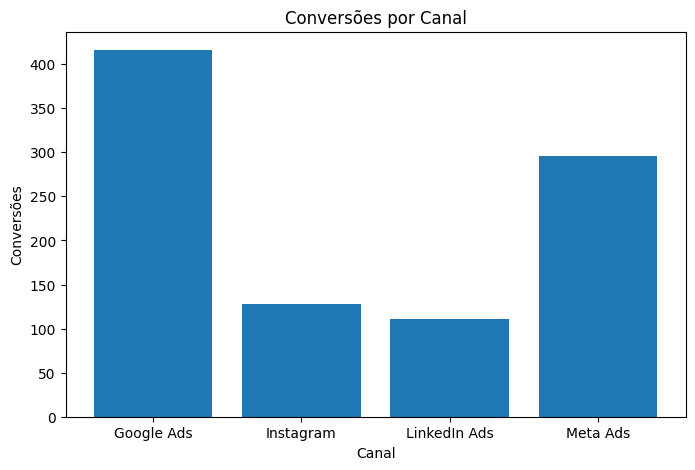

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(resumo['canal'], resumo['conversoes'])

plt.xlabel('Canal')
plt.ylabel('Conversões')
plt.title('Conversões por Canal')

plt.show()

**Gráfico 1:** o Google Ads lidera em conversões (416), seguido por Meta Ads (296), Instagram (128) e LinkedIn Ads (111).

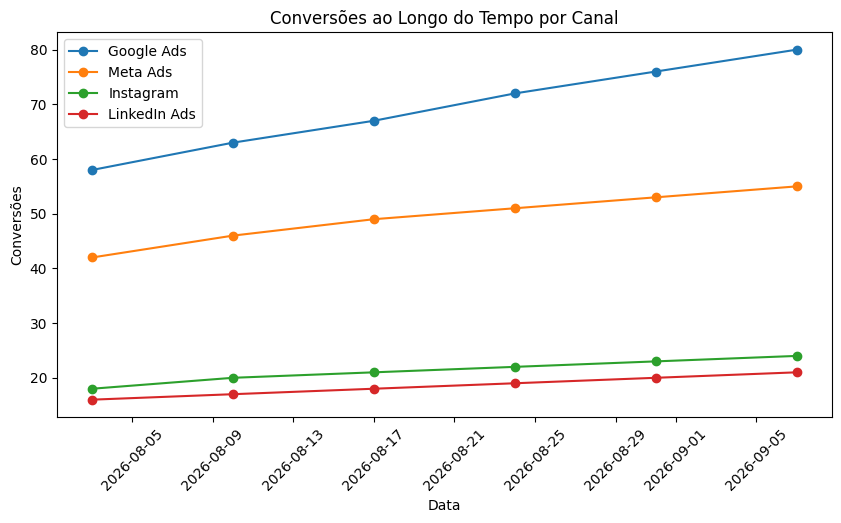

In [ ]:
plt.figure(figsize=(10,5))

for canal in df['canal'].unique():
    dados_canal = df[df['canal'] == canal]
    plt.plot(dados_canal['data'], dados_canal['conversoes'], marker='o', label=canal)

plt.xlabel('Data')
plt.ylabel('Conversões')
plt.title('Conversões ao Longo do Tempo por Canal')
plt.legend()
plt.xticks(rotation=45)

plt.show()

**Gráfico 2:** as conversões cresceram semana a semana em todos os canais (de 03/08 a 07/09), mas o investimento também subiu no período, então isso não prova melhora de desempenho.

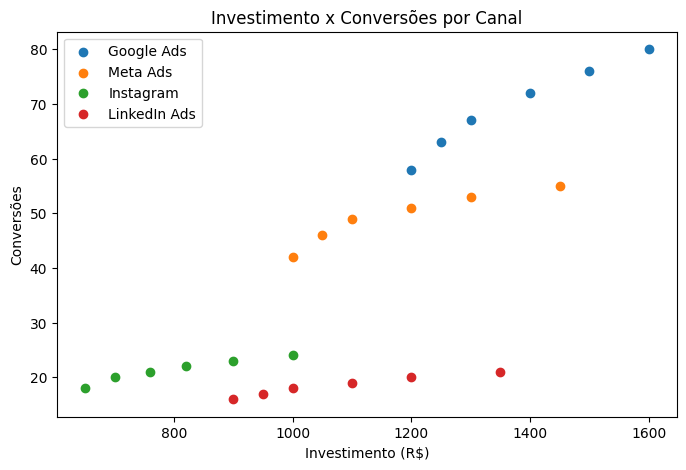

In [ ]:
plt.figure(figsize=(8,5))

for canal in df['canal'].unique():
    dados_canal = df[df['canal'] == canal]
    plt.scatter(
        dados_canal['investimento'],
        dados_canal['conversoes'],
        label=canal
    )

plt.xlabel('Investimento (R$)')
plt.ylabel('Conversões')
plt.title('Investimento x Conversões por Canal')
plt.legend()

plt.show()

**Gráfico 3:** quanto maior o investimento, maior o número de conversões (correlação de 0,79), com o Google Ads convertendo mais por real investido; é uma associação, não prova causalidade.

In [ ]:
df['investimento'].corr(df['conversoes'])

np.float64(0.7857414932427161)

## Resumo dos resultados (informações brutas)

| Canal | Conversões | CTR | Taxa de conversão | CPC | CPA | ROAS |
|---|---|---|---|---|---|---|
| Google Ads | 416 | 5,43% | 2,20% | R\$ 0,44 | R\$ 19,83 | 7,56 |
| Meta Ads | 296 | 2,98% | 1,92% | R\$ 0,46 | R\$ 23,99 | 5,20 |
| Instagram | 128 | 1,96% | 1,05% | R\$ 0,40 | R\$ 37,73 | 2,65 |
| LinkedIn Ads | 111 | 2,89% | 1,82% | R\$ 1,06 | R\$ 58,56 | 5,12 |

* **Melhor desempenho:** Google Ads (maior volume, menor CPA e maior ROAS).
* **Ponto de atenção:** LinkedIn Ads (maior CPA) e Instagram (menor ROAS e menor taxa de conversão).
* **Correlação investimento x conversões:** 0,7857 (associação positiva, sem prova de causalidade).
* **Base:** 24 registros (6 semanas por canal); 1 lead ausente (mantido como NaN) e 1 inconsistência em `canal` (espaço extra em "Instagram "), já corrigida.

## Conclusão

A análise das campanhas mostrou diferenças importantes no desempenho dos canais de Marketing Digital. O Google Ads apresentou o maior volume de conversões, com 416, além de um CPA de R\$ 19,83 e ROAS de 7,56. O Meta Ads também apresentou resultados relevantes, enquanto o Instagram teve o menor ROAS, de 2,65. Já o LinkedIn Ads apresentou o maior CPA, de R\$ 58,56, indicando um custo mais elevado por conversão. A correlação de 0,7857 entre investimento e conversões demonstrou uma associação positiva entre essas variáveis, mas não comprova uma relação de causa e efeito. Portanto, recomenda-se testar possíveis aumentos de investimento no Google Ads e investigar melhorias no LinkedIn Ads. As decisões devem considerar testes adicionais e as limitações dos dados disponíveis.